In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
weights = pd.read_csv("original_data/weights1.csv")
weights2 = pd.read_csv("original_data/weights2.csv")
weights = pd.concat([weights, weights2], ignore_index=True)
weights

,OCCURNUM,qstnum,repwgt0,repwgt1,repwgt2,repwgt3,repwgt4,repwgt5,repwgt6,repwgt7,...,repwgt151,repwgt152,repwgt153,repwgt154,repwgt155,repwgt156,repwgt157,repwgt158,repwgt159,repwgt160
0,1,14,18354163,10438492,10407387,28068302,25562833,9239434,25338398,25701567,...,10895492,31037674,9263588,24989376,8651019,23992521,27458755,22802523,26921460,9028737
1,2,14,15592437,8650848,7739514,23599044,22150186,7661903,20928499,24058785,...,9142763,27457903,8064288,19715055,7889177,20023445,24539323,20821892,22804294,7763269
2,1,15,16356249,8971846,7819705,24359971,21130796,8033700,24966868,21950496,...,8970494,22956112,9292178,25490285,7864233,23294925,19066812,23322929,23187256,8032997
3,1,16,20773863,12256987,10094193,28950309,26670581,8927895,30159278,31383567,...,12579129,30210036,11522337,27180683,9795101,25067470,27903109,29132044,28331760,10088447
4,2,16,16796510,9358118,8017431,25625108,24611988,8170753,24141884,24525276,...,9598023,22642743,10367559,21832240,9384531,22057325,25366842,23213102,23656517,8461291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99058,1,69460,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99059,1,69461,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99060,2,69461,3332493,3369042,3339441,1046782,5289272,3467648,3184734,3487858,...,3398154,3455348,3389339,972960,5565823,1068255,3141941,5549270,5110794,5729614
99061,1,69464,2790829,2731309,837142,830413,4724120,5051157,2624563,5274098,...,4617975,2631165,807997,2960079,812894,4881043,2910442,964690,834369,2604438


In [3]:
data = pd.read_csv('original_data/nov24pub_first_half.csv')
data2 = pd.read_csv('original_data/nov24pub_second_half.csv')
data = pd.concat([data, data2], ignore_index=True)
data

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,84055620110148,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,521800504640811,11,2024,1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,510421864001780,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,7180159540041,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,71062004118993,11,2024,-1,219,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126681,658604017243570,11,2024,-1,218,NaN,2,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126682,140784500685805,11,2024,-1,218,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126683,181202500665725,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126684,940325328011460,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [4]:
data2022 = pd.read_csv("original_data/nov20pub.csv")
data2022.columns = data2022.columns.str.upper()
data2022 = data2022.apply(lambda x: x.str.upper() if x.dtype == "object" else x)

matching_columns = len(set(data.columns) & set(data2022.columns))
print(f"Number of matching columns: {matching_columns}")
# Columns in data but not in data2022
only_in_data = set(data.columns) - set(data2022.columns)
print(f"Columns only in data: {only_in_data}")

# Columns in data2022 but not in data
only_in_data2022 = set(data2022.columns) - set(data.columns)
print(f"Columns only in data2022: {only_in_data2022}")

pct_match_data = matching_columns / len(data.columns) * 100
pct_match_data2022 = matching_columns / len(data2022.columns) * 100
print(f"Percent of data columns in data2022: {pct_match_data:.1f}%")
print(f"Percent of data2022 columns in data: {pct_match_data2022:.1f}%")


# data = data2022

Number of matching columns: 399
Columns only in data: {'PTTLWKHR', 'PRSUPINT', 'PESCK4', 'PRERNMIN', 'PXTLWKHR', 'PXTLWK', 'PTTLWK'}
Columns only in data2022: {'PUSCK4'}
Percent of data columns in data2022: 98.3%
Percent of data2022 columns in data: 99.8%


# IMPUTING

In [5]:
print(data[['PES1', 'PES2']].value_counts())

#Those that can vote, are registered (Or assumption we need to make)
data.loc[data['PES1'] == 1, 'PES2'] = 1

#Inversely, those who aren't registered, can't vote. (Another Assumption)
data.loc[data['PES2'] == 2, 'PES1'] = 2

#If PES2 is 1, and PES1 is NA, then we can assume they are registered, but did not vote. (Another Assumption)
### MAY WANT TO GET RID OF THIS ASSUMPTION, AS IT MAY BE INACCURATE.
data.loc[(data['PES2'] == 1) & (data['PES1'].isna()), 'PES1'] = 2

PES1  PES2
-1    -1      61494
 1    -1      48387
 2     2       8517
       1       5481
-3    -3        877
-2    -2        771
 2    -2        630
-2     1        286
-3     1         77
 2    -3         50
-3    -9         44
 2    -9         30
-2     2         14
-3     2         10
      -2          9
-2    -9          7
      -3          2
Name: count, dtype: int64


In [6]:
def filter_rows_by_negative_one_pct(df, threshold=0.2, missing_value=-1, inplace=False):
    # threshold: fraction of cols with missing_value to mark row as bad
    # e.g. 0.5 means ">= 50% of columns are -1"
    bad = (df == missing_value).sum(axis=1) / df.shape[1] >= threshold
    bad = (df < 0).sum(axis=1) / df.shape[1] >= threshold
    n_bad = int(bad.sum())
    n_total = len(df)
    print(f"{n_bad} rows out of {n_total} have >= {threshold*100:.1f}% of columns == {missing_value}")
    if inplace:
        df.drop(index=df[bad].index, inplace=True)
        print(f"dropped {n_bad} rows, remaining {len(df)} rows")
        return df
    df_clean = df.loc[~bad].reset_index(drop=True)
    print(f"returning cleaned df with {len(df_clean)} rows")
    return df_clean

### USED TO CREATE PRE AND POST DROP COMPARISON PLOTS --- IGNORE ---

# df_clean = filter_rows_by_negative_one_pct(data)

# thresholds = np.linspace(0.0, 1.0, 101)
# remaining_counts = []

# for t in thresholds:
#     df_tmp = filter_rows_by_negative_one_pct(data, threshold=t)
#     remaining_counts.append(len(df_tmp))

# print("data original shape:", data.shape)
# print("rows remaining at thresholds (0..100%):", remaining_counts[:5], "...", remaining_counts[-5:])

# plt.figure(figsize=(8, 5))
# plt.plot(thresholds * 100, remaining_counts, marker="o", markersize=3)
# plt.xlabel("threshold % of columns == -1")
# plt.ylabel("rows remaining")
# plt.title("Rows remaining after filtering at each -1 threshold PreDrop")
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(remaining_counts, bins=20, edgecolor="k")
# plt.xlabel("rows remaining")
# plt.ylabel("frequency")
# plt.title("Histogram of remaining row counts over thresholds")
# plt.show()


# CLEANING DATA
Removing values/rows that aren't elgible to our dicussion of voter elgibility/didn't answer

Along with weights and flag columns that are superfrillous

In [7]:
data['HRINTSTA'].value_counts()

# 1 = Interview

# 2 = Type A Noninterview (These records represent households that were eligible
# for the November CPS interview but were not interviewed because no one was
# home, household members were temporarily absent, etc.)

# 3 = Type B Noninterview (These records represent sample addresses determined to
# be ineligible for the CPS by virtue of a temporary situation, such as being
# vacant, nonresidential, etc. These households could become eligible for a CPS
# interview.)

# 4 = Type C Noninterview (These records represent sample addresses determined to be
# ineligible for CPS by virtue of a permanent change such as demolished,
# condemned, etc. These addresses will not be visited again for CPS interviews.)

# We should only keep rows where HRINTSTA == 1, as these are the only rows that represent actual interviews. The other rows represent non-interviews or ineligible addresses, which are not useful for our analysis.
data = data[data['HRINTSTA'] == 1].reset_index(drop=True)

In [8]:
### PRCITSHP (CITIZENSHIP STATUS)

# 1 NATIVE, BORN IN THE UNITED STATES
# 2 NATIVE, BORN IN PUERTO RICO OR OTHER U.S. ISLAND AREAS
# 3 NATIVE, BORN ABROAD OF AMERICAN PARENT OR PARENTS
# 4 FOREIGN BORN, U.S. CITIZEN BY NATURALIZATION
# 5 FOREIGN BORN, NOT A CITIZEN OF THE UNITED STATES

# We should only keep rows where PRCITSHP != 5, as these are the only rows that don't represent elgible voters.

data = data[data['PRCITSHP'] != 5].reset_index(drop=True)


### PRCITSHP (CITIZENSHIP STATUS)

# 1 = Child household member (0-14 years old)
# 2 = Adult household member (15 years and older)
# 3 = Reference person (the first adult household member listed in the household roster)

# We need to drop rows where PRPERTYP == 1, as these represent child household members who are not eligible voters and do not provide useful information for our analysis. 
# MAY NEED TO CHANGE THIS TO PRPERTYP == 2, AS THIS REPRESENTS ADULT HOUSEHOLD MEMBERS, WHICH MAY BE MORE RELEVANT TO OUR ANALYSIS. NEED TO INVESTIGATE FURTHER.
data = data[data['PRPERTYP'] != 1].reset_index(drop=True)

In [9]:
print(data[['PES1', 'PES2']].value_counts())


## We may want to remove rows where PES1/PES2 are negative,
#  who don't know if they voted, or wouldn't tell, 
# removes binary-ness of the target variable, but we can try both ways and 
# see which performs better. We can also try to impute these values in some way,
#  or create a separate category for "unknown" if we want to keep them.


#### BIG PROBLEM WITH PES2 (LOTS OF -1s, WHICH MAY BE NOISY OR UNRELIABLE)
data = data[(data['PES1'] >= 0) & (data['PES2'] >= 0)].reset_index(drop=True)



PES1  PES2
 1     1      48387
-1    -1      11225
 2     2       8541
       1       5481
-3    -3        877
-2    -2        771
 2    -2        630
-2     1        286
-3     1         77
 2    -3         50
-3    -9         44
 2    -9         30
-3    -2          9
-2    -9          7
      -3          2
Name: count, dtype: int64


In [10]:
data = data.drop(columns=[col for col in data.columns if col.startswith('PX') or col.startswith('HX')])

# Used to Drop Flags and Allocation Weights,
#  which are not useful for our analysis and may introduce noise or bias into our models.
#  These columns often contain binary indicators or weights that are specific to the survey
#  design and may not be relevant for predicting voter turnout or registration status. 
# By dropping these columns, we can focus on the demographic and socioeconomic features 
# that are more likely to be informative for our analysis.

In [11]:


# Identify columns where all values are -1
cols_to_drop = [col for col in data.columns if (data[col] == -1).all()]

# Drop those columns from data
data = data.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")

Dropped 10 columns: ['HUTYPEA', 'HUTYPB', 'HUTYPC', 'PULKDK3', 'PULKDK4', 'PULKDK5', 'PULKDK6', 'PULKPS4', 'PULKPS5', 'PULKPS6']


# Creating Readable Table for descriptive characteristics

In [12]:
(data.where(data == -1).count() / len(data) * 100).sort_values(ascending=False).head(90)
# We can also get rid of columns that have a certain percentage of NA values, as these are also likely to be uninformative. 
# We can also get rid of columns that have a certain percentage of 0 values, as these are also likely to be uninformative. 


### Values that have 0% of -1 values (i.e. no missing data)

# HRHHID    HOUSEHOLD IDENTIFIER
# GTCBSA    SPECIFIC METROPOLITAN CBSA CODE  (SEE GEOGRAPHIC ATTACHMENT)
# GTCO      FIPS COUNTY CODE
# GTCBSAST  PRINCIPAL CITY/BALANCE STATUS 
# GTMETSTA  METROPOLITAN STATUS
# GTINDVPC  INDIVIDUAL PRINCIPAL CITY
# GTCBSASZ  Metropolitan Area (CBSA) SIZE (Population)
# GTCSA     Consolidated Statistical Area (CSA) FIPS CODE (SEE GEOGRAPHIC ATTACHMEN
# PTWK      WEEKLY EARNINGS – TOP CODE ****
# PRTFAGE   TOP CODE FLAG FOR AGE **** 
# PWCMPWGT  Composited Final Weight. Used to create BLS's published labor force statistics (4 implied decimal places)
# PTOT      WEEKLY OVERTIME AMOUNT – TOP CODE ****
# GEDIV     DIVISION
# OCCURNUM  Unique person identifier. Valid only within any specific month. 
# HXPHONEO  ALLOCATION FLAG 
# HXTELAVL  ALLOCATION FLAG  
# HXTELHHD  ALLOCATION FLAG
# HXFAMINC  ALLOCATION FLAG
# HXHOUSUT  ALLOCATION FLAG
# HXTENURE  ALLOCATION FLAG
# PWFMWGT   FAMILY WEIGHT (4 IMPLIED DECIMALS) ONLY USED FOR TALLYING FAMILY CHARACTERISTICS.
# PWLGWGT   LONGITUDINAL WEIGHT (4 IMPLIED DECIMALS) ONLY FOUND ON ADULT RECORDS MATCHED FROM MONTH TO MONTH. (USED FOR GROSS FLOWS ANALYSIS)
# PWORWGT   OUTGOING ROTATION WEIGHT (4 IMPLIED DECIMALS) USED FOR TALLYING INFORMATION COLLECTED ONLY IN 
# PWSSWGT   FINAL WEIGHT (4 IMPLIED DECIMAL PLACES) USED FOR MOST TABULATIONS, CONTROLLED TO INDEPENDENT ESTIMATES FOR 1) STATES; 2) ORIGIN, SEX, AND AGE; AND 3) AGE, RA 
# PWVETWGT  VETERANS WEIGHT (4 IMPLIED DECIMALS) USED FOR TALLYING VETERAN'S DATA ONLY, CONTROLLED TO ESTIMATES OF VETERANS SUPPLIED BY
# QSTNUM    Unique household identifier. Valid only within any specific month. 
# GEREG     REGION
# GESTFIPS  STATE CODE
# HUFINAL   FINAL OUTCOME CODE 
# PTHR      HOURLY PAY – TOP CODE ****
# HWHHWGT   HOUSEHOLD WEIGHT (4 IMPLIED DECIMAL PLACES) USED FOR TALLYING HOUSEHOLD CHARACTERISTICS  
# HEPHONEO  IS A TELEPHONE INTERVIEW ACCEPTABLE?
# HRNUMHOU  TOTAL NUMBER OF PERSONS LIVING IN THE HOUSEHOLD (HOUSEHOLD MEMBERS)
# HRHTYPE   HOUSEHOLD TYPE
# HRMIS     MONTH-IN-SAMPLE 
# HRLONGLK  LONGITUDINAL LINK INDICATOR EDITED UNIVERSE: ALL HHLDs IN SAMPLE 
# HRHHID2   HOUSEHOLD IDENTIFIER (part 2)
# HRYEAR4   YEAR OF INTERVIEW
# HEHOUSUT  TYPE OF HOUSING UNIT
# HRMONTH   MONTH OF INTERVIEW 
# HUPRSCNT  NUMBER OF ACTUAL AND ATTEMPTED PERSONAL CONTACTS

PULKPS3     99.998398
PTERNH1C    99.996795
PULKDK2     99.995193
PULKPS2     99.995193
PTERN2      99.993591
              ...    
PRUNEDUR    97.892932
PTERNH2     97.751927
PEHGCOMP    97.375379
HUBUSL2     97.224759
PUBUS1      96.936339
Length: 90, dtype: float64

In [13]:
for df_name in ['data', 'data2']:
    if df_name in globals():
        df = globals()[df_name]
        keep = ~(df == -1).all(axis=1)
        globals()[df_name] = df.loc[keep].reset_index(drop=True)
        print(f"{df_name}: removed {len(df) - keep.sum()} rows, remaining {keep.sum()}")

data: removed 0 rows, remaining 62409
data2: removed 0 rows, remaining 63343


In [14]:
### MADE A READABLE VERSION OF THE CATEGORICAL VARIABLES USING THE CODEBOOK

LABELS = {
    "PESEX":    {1: "Male", 2: "Female"},
    "PEHSPNON": {1: "Hispanic", 2: "Non-Hispanic"},
    "PRCITSHP": {1: "Native-born", 2: "Born PR/territory",
                 3: "Born abroad-US parents", 4: "Naturalized", 5: "Non-citizen"},
    "PEEDUCA":  {
        31: "Less than 1st grade", 32: "1st-4th grade", 33: "5th-6th grade",
        34: "7th-8th grade", 35: "9th grade", 36: "10th grade",
        37: "11th grade", 38: "12th no diploma", 39: "HS diploma/GED",
        40: "Some college", 41: "Associate-vocational", 42: "Associate-academic",
        43: "Bachelor's", 44: "Master's", 45: "Professional", 46: "Doctorate",
    },
    "PRMARSTA": {1: "Married-civ spouse", 2: "Married-AF spouse",
                 3: "Married-spouse absent", 4: "Widowed",
                 5: "Divorced", 6: "Separated", 7: "Never married"},
    "PEMLR":    {1: "Employed-at work", 2: "Employed-absent",
                 3: "Unemployed-layoff", 4: "Unemployed-looking",
                 5: "NILF-retired", 6: "NILF-disabled", 7: "NILF-other"},
    "PTDTRACE": {1: "White", 2: "Black", 3: "AI/AN", 4: "Asian",
                 5: "PI", 6: "White-Black", 7: "White-AI/AN", 8: "White-Asian",
                 9: "White-PI", 10: "Black-AI/AN", 11: "Black-Asian",
                 12: "Black-PI", 13: "AI/AN-Asian",
                 14: "Asian-PI", 15: "White-Black-AI/AN", 16: "White-Black-Asian",
                 17: "White-Black-PI", 18: "White-AI/AN-Asian",
                 19: "White-AI/AN-PI", 20: "White-Asian-PI",
                 21: "Black-AI/AN-Asian", 22: "Black-AI/AN-PI",
                 23: "Black-Asian-PI", 24: "AI/AN-Asian-PI",
                 25: "White-Black-AI/AN-Asian", 26: "Other 3+ race combo"},
    "GTMETSTA": {1: "Principal city", 2: "Balance of metro", 3: "Nonmetropolitan"},
    "PEAFEVER": {1: "Veteran", 2: "Non-veteran"},
    "PRDISFLG": {1: "Has disability", 2: "No disability"},
    "HEFAMINC": {
        1: "<$5k", 2: "$5-7.5k", 3: "$7.5-10k", 4: "$10-12.5k",
        5: "$12.5-15k", 6: "$15-20k", 7: "$20-25k", 8: "$25-30k",
        9: "$30-35k", 10: "$35-40k", 11: "$40-50k", 12: "$50-60k",
        13: "$60-75k", 14: "$75-100k", 15: "$100-150k", 16: "$150k+",
    },
}
readable_data = data.copy()

MISSING_SENTINEL = [-1, -2, -3, -9]

for col, mapping in LABELS.items():
    if col in readable_data.columns:
        readable_data[col] = readable_data[col].replace(MISSING_SENTINEL, np.nan).map(mapping)

readable_data.head()

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,6,4,2
1,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,6,4,1
2,50057098511186,11,2024,1,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,9,4,1
3,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,-2,4,1
4,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,-2,4,1


# Nonresponse Exploration
Finding how many rows have what percentage of nonresponse

62409 rows out of 62409 have >= 20.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 0.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 1.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 2.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 3.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 4.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 5.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 6.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 7.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 8.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 9.0% of columns == -1
returning cleaned df with 0 rows
62409 rows out of 62409 have >= 10.0% of c

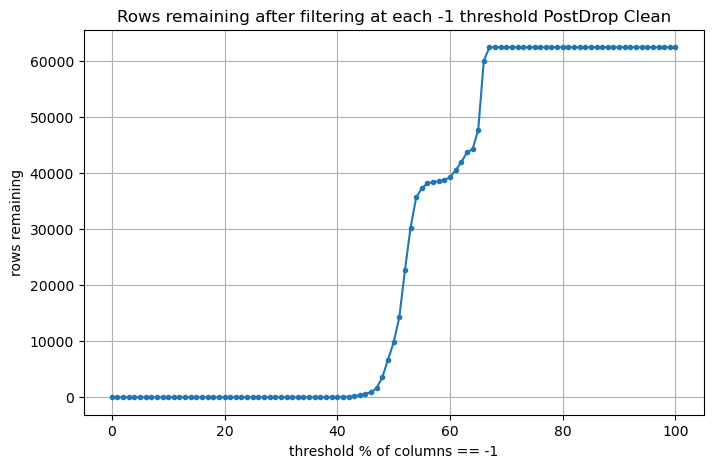

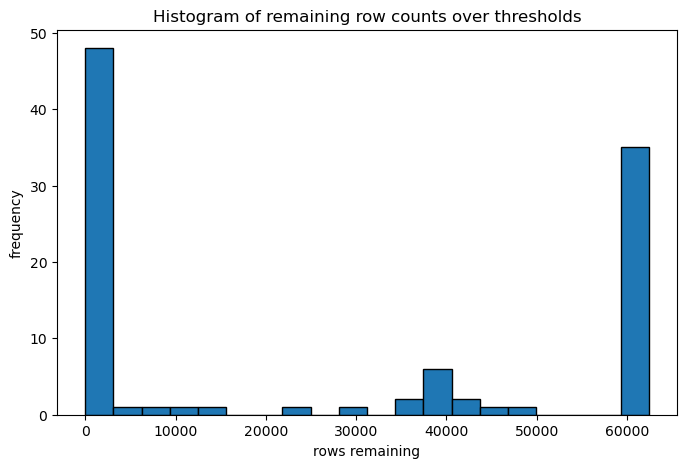

In [15]:
df_clean = filter_rows_by_negative_one_pct(data)

thresholds = np.linspace(0.0, 1.0, 101)
remaining_counts = []

for t in thresholds:
    df_tmp = filter_rows_by_negative_one_pct(data, threshold=t)
    remaining_counts.append(len(df_tmp))

print("data original shape:", data.shape)
print("rows remaining at thresholds (0..100%):", remaining_counts[:5], "...", remaining_counts[-5:])

plt.figure(figsize=(8, 5))
plt.plot(thresholds * 100, remaining_counts, marker="o", markersize=3)
plt.xlabel("threshold % of columns == -1")
plt.ylabel("rows remaining")
plt.title("Rows remaining after filtering at each -1 threshold PostDrop Clean")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(remaining_counts, bins=20, edgecolor="k")
plt.xlabel("rows remaining")
plt.ylabel("frequency")
plt.title("Histogram of remaining row counts over thresholds")
plt.show()

Appears post cleaning about all rows may have about 40% of values that are -1

In [16]:
data['PRPERTYP'].value_counts(dropna=False)

PRPERTYP
2    62409
Name: count, dtype: int64

In [17]:
len(data['GESTFIPS'].unique())

51

In [18]:
data

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,6,4,2
1,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,6,4,1
2,50057098511186,11,2024,1,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,9,4,1
3,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,-2,4,1
4,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,-2,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62404,740955848011240,11,2024,1,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,2,6,4,1
62405,740955848011240,11,2024,1,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,2,6,4,2
62406,651408019271540,11,2024,1,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,8,4,1
62407,75183059016886,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,2,8,4,2


In [19]:
# data.to_csv("clean_data/nov20pub_clean.csv", index=False)

In [20]:
matching_columns = len(set(data.columns) & set(data2022.columns))
print(f"Number of matching columns: {matching_columns}")

Number of matching columns: 284


In [21]:
data2020 = pd.read_csv("original_data/nov20pub.csv")

matching_columns = len(set(data.columns) & set(data2020.columns))
print(f"Number of matching columns: {matching_columns}")

Number of matching columns: 271


In [22]:
# def compare_columns(main_df: pd.DataFrame, other_dfs: dict[str, pd.DataFrame]) -> None:
#     """
#     Compares column names of other DataFrames against a main DataFrame.

#     Args:
#         main_df:    The reference DataFrame (your main CPS file).
#         other_dfs:  A dict mapping a label (e.g. filename) to each DataFrame to compare.
#     """
#     main_cols = set(main_df.columns)
#     n_main = len(main_cols)

#     rows = []
#     for label, df in other_dfs.items():
#         other_cols = set(df.columns)
#         matching = main_cols & other_cols
#         only_in_main = main_cols - other_cols
#         only_in_other = other_cols - main_cols

#         rows.append({
#             "File": label,
#             "Main cols": n_main,
#             "Other cols": len(other_cols),
#             "Matching": len(matching),
#             "Match %": f"{100 * len(matching) / n_main:.1f}%",
#             "Only in main": len(only_in_main),
#             "Only in other": len(only_in_other),
#         })

#     summary = pd.DataFrame(rows).set_index("File")
#     print(summary.to_string())


# main_df   = load_cps_dat("data/main_file.dat", dictionary)
# supp1_df  = load_cps_dat("data/supplement1.dat", dictionary)
# supp2_df  = load_cps_dat("data/supplement2.dat", dictionary)

# compare_columns(
#     main_df,
#     {
#         "supplement1.dat": supp1_df,
#         "supplement2.dat": supp2_df,
#     }
# )

In [23]:
# from cps_utils import parse_cps_layout, load_cps_dat, load_all_cps_dat, compare_columns

# layout  = parse_cps_layout("original_data/cpsnov18.txt")         # parse column positions
# main_df = load_cps_dat("original_data/nov18pub.dat", layout)
# others  = load_all_cps_dat("original_data/", layout)
# others.pop("nov18pub.dat")                   # remove main from comparison

# compare_columns(main_df, others, verbose=True)      # verbose=True shows actual column name diffs

## Actual EDA

In [24]:
print(data['PES1'].value_counts())
print(data['PES2'].value_counts())
data[["PES1", "PES2"]].value_counts(dropna=False)   

PES1
1    48387
2    14022
Name: count, dtype: int64
PES2
1    53868
2     8541
Name: count, dtype: int64


PES1  PES2
1     1       48387
2     2        8541
      1        5481
Name: count, dtype: int64

In [25]:
corr = data.corr()[['PES1', 'PES2']]
corr_sorted = corr.abs().sort_values(by=['PES1', 'PES2'], ascending=False)
corr_sorted.head(20)

,PES1,PES2
PES1,1.000000,0.739688
PES6,0.885883,0.655277
PES5,0.885076,0.654679
PES2,0.739688,1.000000
PES3,0.672254,0.908835
PES4,0.500556,0.107296
PES7,0.316644,0.392584
PEEDUCA,0.297341,0.267369
HEFAMINC,0.213419,0.180287
PEMARITL,0.197892,0.161610


In [26]:
## Cramer's V for categorical variables
from scipy.stats import chi2_contingency


#This measures association between two categorical variables 
# regardless of coding order. It gives you a 0–1 score like a correlation:

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(r-1, k-1))

In [27]:
nominal_cols = ["PTDTRACE", "PESEX", "PEHSPNON", "PRMARSTA", 
               "PEMLR", "GTMETSTA", "PRCITSHP", "PEAFEVER", "PRDISFLG"]


target = "PES1"  # or Voted in 2024 or not

results = {}
for col in nominal_cols:
    subset = df[[col, target]].dropna()
    results[col] = cramers_v(subset[col], subset[target])

pd.Series(results).sort_values(ascending=False)

PEAFEVER    0.555706
PRDISFLG    0.536298
PEHSPNON    0.415765
PESEX       0.396636
PEMLR       0.394873
PRMARSTA    0.390976
PRCITSHP    0.318866
PTDTRACE    0.285559
GTMETSTA    0.030310
dtype: float64

In [28]:
target = "PES2" # Registered to vote in 2024 or not

results = {}
for col in nominal_cols:
    subset = df[[col, target]].dropna()
    results[col] = cramers_v(subset[col], subset[target])

pd.Series(results).sort_values(ascending=False)

PEAFEVER    0.232766
PRDISFLG    0.229123
PEHSPNON    0.166870
PESEX       0.165645
PRMARSTA    0.155456
PEMLR       0.153982
PRCITSHP    0.125137
PTDTRACE    0.109329
GTMETSTA    0.026307
dtype: float64

In [29]:
import numpy as np

conditions = [
    data['PES1'] == 1,
    (data['PES1'] == 2) | (data['PES2'] == 2)
]
choices = [1, 2]
data['target_column'] = np.select(conditions, choices, default=np.nan)

In [30]:
data['target_column'].value_counts(dropna=False)

target_column
1.0    48387
2.0    14022
Name: count, dtype: int64

In [31]:
target = "target_column" #Voted in 2024 or not + all non registered to vote as not voting

results = {}
for col in nominal_cols:
    subset = data[[col, target]].dropna()
    results[col] = cramers_v(subset[col], subset[target])

pd.Series(results).sort_values(ascending=False)

PEMLR       0.203487
PRMARSTA    0.203153
PEHSPNON    0.128652
PTDTRACE    0.081432
PRCITSHP    0.075962
PRDISFLG    0.068772
PEAFEVER    0.040806
PESEX       0.031723
GTMETSTA    0.030784
dtype: float64

In [32]:
#FAMD

In [33]:
readable_data['HEFAMINC'].value_counts(dropna=False)

HEFAMINC
$150k+       14271
$100-150k    11077
$75-100k      8611
$60-75k       6281
$50-60k       4489
$40-50k       4030
$35-40k       2495
$30-35k       2435
$20-25k       1956
$25-30k       1874
$15-20k       1290
<$5k           987
$10-12.5k      975
$12.5-15k      859
$5-7.5k        404
$7.5-10k       375
Name: count, dtype: int64

In [34]:
from cps_utils import parse_cps_layout, build_layout_map, load_cps_dat, load_all_cps_dat, compare_columns

folder_data = "original_data"
folder_text = "txt_files"
main_file = "nov18pub.dat"

# Map each .dat file to its year's documentation .txt
pairs = {
    "nov18pub.dat": f"{folder_text}/cpsnov18.txt",
    "nov16pub.dat": f"{folder_text}/cpsnov16.txt",
    "nov14pub.dat": f"{folder_text}/cpsnov14.txt",
    "nov12pub.dat": f"{folder_text}/cpsnov12.txt",
    "nov10pub.dat": f"{folder_text}/cpsnov10.txt"
}

layout_map = build_layout_map(pairs)
#main_df    = load_cps_dat(f"{folder_data}/{main_file}", layout_map[main_file])
all_dfs    = load_all_cps_dat(folder_data, layout_map)
other_dfs  = {k: v for k, v in all_dfs.items() } # if k != main_file}

compare_columns(data, other_dfs, verbose=True)

  nov18pub.dat: 388 columns parsed from txt_files/cpsnov18.txt
  nov16pub.dat: 386 columns parsed from txt_files/cpsnov16.txt
  nov14pub.dat: 381 columns parsed from txt_files/cpsnov14.txt
  nov12pub.dat: 381 columns parsed from txt_files/cpsnov12.txt
  nov10pub.dat: 386 columns parsed from txt_files/cpsnov10.txt
  Loading nov18pub.dat (388 columns)...
  Loading nov16pub.dat (386 columns)...
  Loading nov14pub.dat (381 columns)...
  Loading nov12pub.dat (381 columns)...
  Loading nov10pub.dat (386 columns)...

--- nov18pub.dat ---
  Only in main  (28): ['FILLER', 'PEPAR1', 'PEPAR1TYP', 'PEPAR2', 'PEPAR2TYP', 'PES3', 'PES7', 'PESCK4', 'PRDASIAN', 'PRERNMIN', 'PRINUYER', 'PRSUPINT', 'PTDTRACE', 'PTERN', 'PTERN2', 'PTERNH1C', 'PTERNH1O', 'PTERNH2', 'PTERNHLY', 'PTERNWA', 'PTIO1OCD', 'PTIO2OCD', 'PTTLWK', 'PTTLWKHR', 'PUCHINHH', 'PUHRCK12', 'PULINENO', 'target_column']
  Only in other (126): ['HUSPNISH', 'HUTYPB', 'HUTYPC', 'HUTYPEA', 'HXFAMINC', 'HXHOUSUT', 'HXPHONEO', 'HXTELAVL', 'HXTELH

In [ ]:
data2018 = load_cps_dat("original_data/nov18pub.dat", layout_map["nov18pub.dat"])

In [ ]:
data2018['HRYEAR4'].value_counts()